In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

%matplotlib inline

In [3]:
diabetes = pd.read_csv('diabetes.csv')

diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [4]:
print('Rows, Columns:', diabetes.shape)

print('\nColumn names:')
print(list(diabetes.columns))


Rows, Columns: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [5]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [6]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
missing_count = diabetes.isnull().sum()

missing_percent = (missing_count / len(diabetes)) * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent.round(2)
})

missing_summary = missing_summary[missing_summary['missing_count'] > 0]
missing_summary = missing_summary.sort_values('missing_percent', ascending=False)

print('Columns with missing values, worst first:')
missing_summary

Columns with missing values, worst first:


,missing_count,missing_percent
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


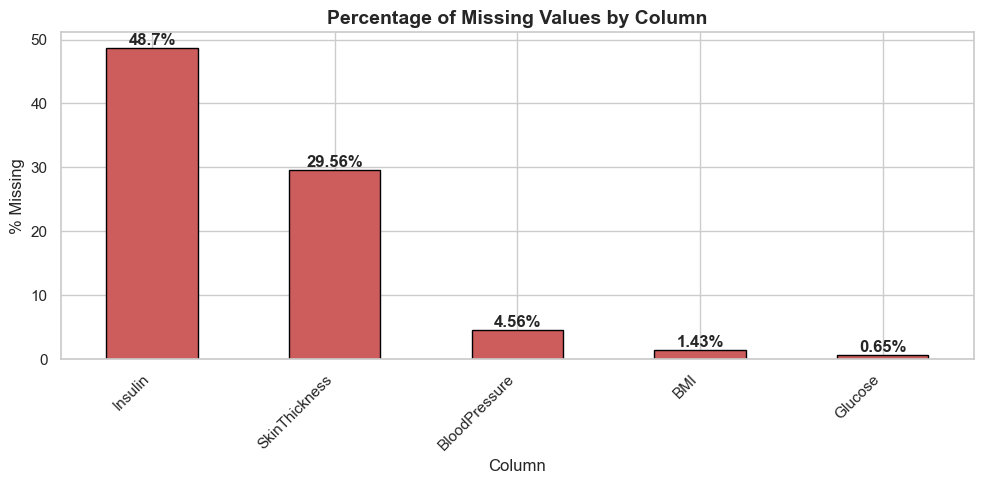

In [8]:
plt.figure(figsize=(10, 5))

ax = missing_summary['missing_percent'].plot(kind='bar', color='indianred', edgecolor='black')

plt.title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
plt.ylabel('% Missing')
plt.xlabel('Column')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(missing_summary['missing_percent']):
    ax.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()  # Prevents labels from being cut off at the edges of the figure
plt.show()

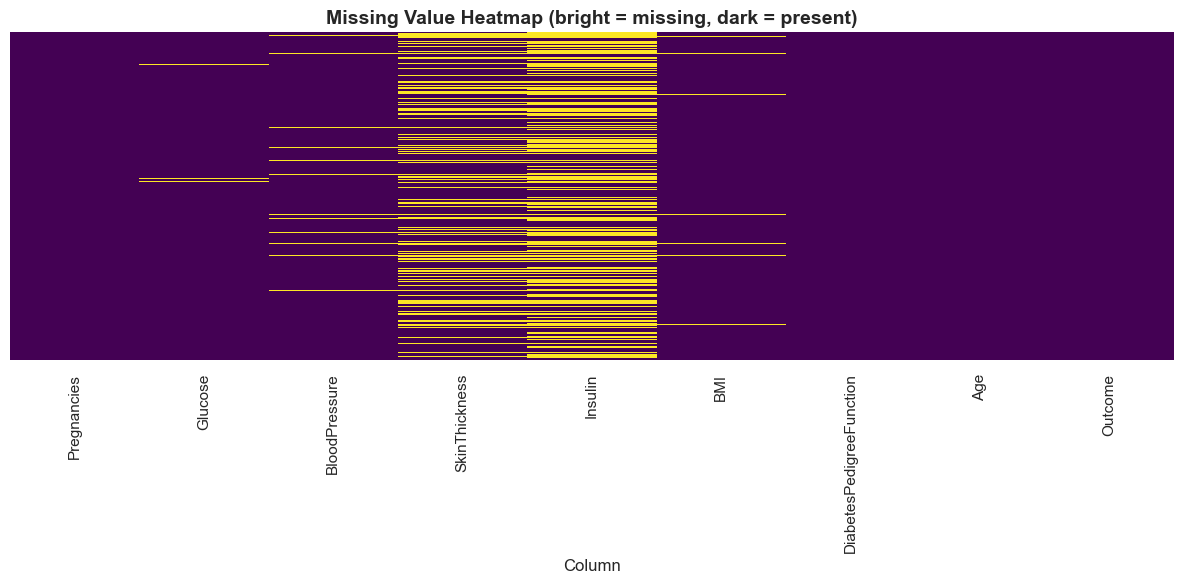

In [9]:
plt.figure(figsize=(12, 6))

sns.heatmap(diabetes.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Value Heatmap (bright = missing, dark = present)', fontsize=14, fontweight='bold')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

In [10]:
diabetes_clean = diabetes.copy()

print('Missing values BEFORE cleaning:')
print(diabetes_clean.isnull().sum()[diabetes_clean.isnull().sum() > 0])

Missing values BEFORE cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


### Handling Missing Values in Insulin

Insulin has 374 missing values, representing approximately 48.7% of the dataset. Since almost half of the observations are missing, replacing these values with a single statistic such as the median could introduce substantial bias and reduce the reliability of the variable.

Rather than removing a large number of patient records, I decided to remove the Insulin column from the analysis. This allows the remaining variables with better data completeness to be used without losing a large portion of the dataset.

This decision is specific to this analysis and would need to be reconsidered if Insulin were essential to the research question.

In [11]:
diabetes_clean = diabetes_clean.drop(columns=['Insulin'])

print('Columns remaining after dropping Insulin:')
print(list(diabetes_clean.columns))

Columns remaining after dropping Insulin:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


### Handling Missing Values in SkinThickness

SkinThickness contains 227 missing values, representing approximately 29.6% of the dataset. Because removing these rows would reduce the sample size considerably, I chose median imputation.

The median was selected instead of the mean because it is less sensitive to extreme values and provides a simple robust estimate for replacing the missing observations.

The limitation is that median imputation reduces the natural variability of the variable because many missing observations receive the same value. Therefore, this variable should be interpreted with some caution.

In [12]:
median_SkinThickness = diabetes_clean['SkinThickness'].median()
print(f'Median SkinThickness (calculated from non-missing rows): {median_SkinThickness}')

# .fillna(value) replaces every NaN in the column with the given value.
diabetes_clean['SkinThickness'] = diabetes_clean['SkinThickness'].fillna(median_SkinThickness)

# Double-check: there should now be ZERO missing values left in 'SkinThickness'
print('Missing values remaining in SkinThickness:', diabetes_clean['SkinThickness'].isnull().sum())


Median SkinThickness (calculated from non-missing rows): 29.0
Missing values remaining in SkinThickness: 0


In [13]:
median_Glucose = diabetes_clean['Glucose'].median()
print(f'Median Glucose (calculated from non-missing rows): {median_Glucose}')

# .fillna(value) replaces every NaN in the column with the given value.
diabetes_clean['Glucose'] = diabetes_clean['Glucose'].fillna(median_Glucose)

# Double-check: there should now be ZERO missing values left in 'Glucose
print('Missing values remaining in Glucose:', diabetes_clean['Glucose'].isnull().sum())


Median Glucose (calculated from non-missing rows): 117.0
Missing values remaining in Glucose: 0


In [14]:
median_BloodPressure = diabetes_clean['BloodPressure'].median()
print(f'Median BloodPressure (calculated from non-missing rows): {median_BloodPressure}')

# .fillna(value) replaces every NaN in the column with the given value.
diabetes_clean['BloodPressure'] = diabetes_clean['BloodPressure'].fillna(median_BloodPressure)

# Double-check: there should now be ZERO missing values left in 'BloodPressure'
print('Missing values remaining in BloodPressure:', diabetes_clean['BloodPressure'].isnull().sum())


Median BloodPressure (calculated from non-missing rows): 72.0
Missing values remaining in BloodPressure: 0


In [15]:
median_BMI = diabetes_clean['BMI'].median()
print(f'Median BMI (calculated from non-missing rows): {median_BMI}')

# .fillna(value) replaces every NaN in the column with the given value.
diabetes_clean['BMI'] = diabetes_clean['BMI'].fillna(median_BMI)

# Double-check: there should now be ZERO missing values left in 'BMI'
print('Missing values remaining in BMI:', diabetes_clean['BMI'].isnull().sum())


Median BMI (calculated from non-missing rows): 32.3
Missing values remaining in BMI: 0


In [16]:
rows_before = len(diabetes_clean)

# .dropna() with no arguments removes any ROW that still contains at least one NaN
diabetes_clean = diabetes_clean.dropna()

rows_after = len(diabetes_clean)
print(f'Rows before final dropna: {rows_before}')
print(f'Rows after final dropna:  {rows_after}')
print(f'Rows removed: {rows_before - rows_after}')

Rows before final dropna: 768
Rows after final dropna:  768
Rows removed: 0


In [17]:
remaining_missing = diabetes_clean.isnull().sum()
total_remaining = remaining_missing.sum()

print('Missing values per column AFTER cleaning:')
print(remaining_missing)
print(f'\nTotal missing values remaining in the whole dataset: {total_remaining}')

Missing values per column AFTER cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values remaining in the whole dataset: 0


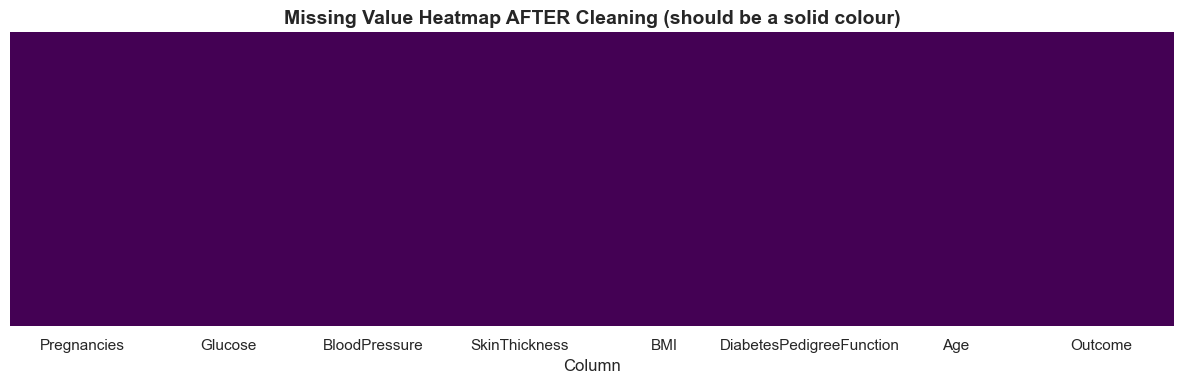

In [18]:
plt.figure(figsize=(12, 4))
sns.heatmap(diabetes_clean.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap AFTER Cleaning (should be a solid colour)', fontsize=14, fontweight='bold')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

In [19]:
diabetes.duplicated().sum()

np.int64(0)

In [20]:
diabetes.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [21]:
diabetes.nunique()

Pregnancies                  17
Glucose                     135
BloodPressure                46
SkinThickness                50
Insulin                     185
BMI                         247
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [22]:
# Check the size of the dataset after cleaning
print("Dataset shape:", diabetes_clean.shape)

# Check missing values in every column
print("\nMissing values:")
print(diabetes_clean.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", diabetes_clean.duplicated().sum())

Dataset shape: (768, 8)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0


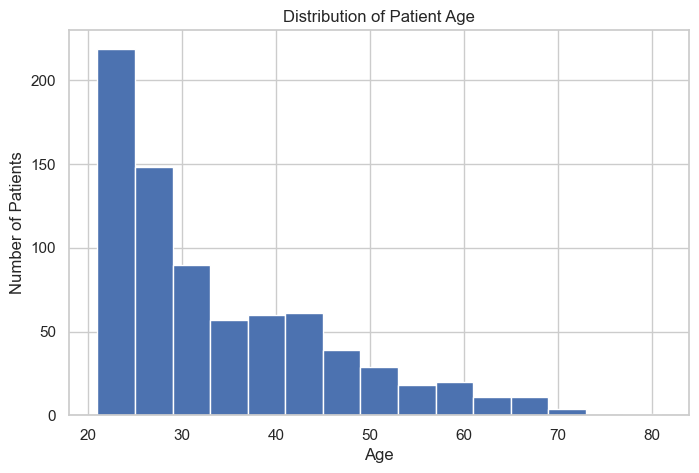

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(diabetes_clean['Age'], bins=15)

plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

### Interpretation

The age distribution is concentrated among younger adults, particularly those in their 20s and 30s. The number of patients decreases as age increases, meaning older age groups are less represented in this dataset.

However, this distribution alone does not tell us whether older patients are more likely to have a diabetes outcome. To investigate this, age needs to be compared with the Outcome variable.

In [24]:
# Count zero values in every column

(diabetes_clean == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [25]:
zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'BMI'
]

for column in zero_columns:
    print(f"{column}: {(diabetes_clean[column] == 0).sum()} zero values")

Glucose: 0 zero values
BloodPressure: 0 zero values
SkinThickness: 0 zero values
BMI: 0 zero values


## Is Age Associated With Diabetes Outcome?
To investigate whether diabetes outcomes differ across age groups, I first compared the average age of patients with and without a diabetes outcome.

In [26]:
diabetes_clean.groupby('Outcome')['Age'].mean()

Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64

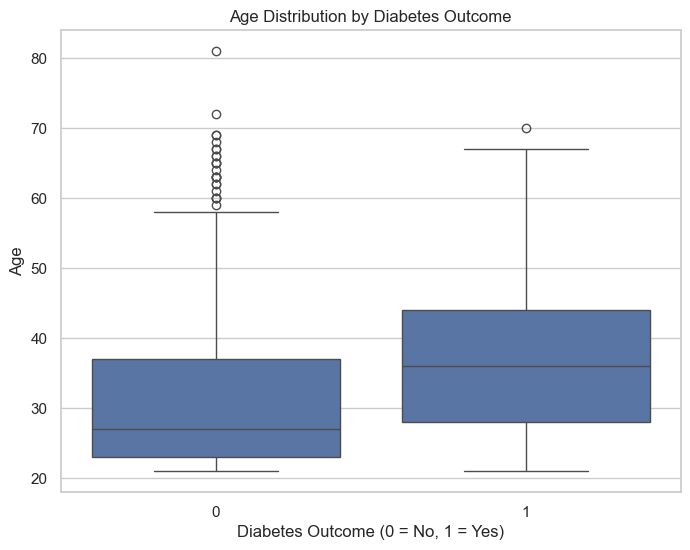

In [27]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=diabetes_clean,
    x='Outcome',
    y='Age'
)

plt.title('Age Distribution by Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No, 1 = Yes)')
plt.ylabel('Age')

plt.show()

### Interpretation

Patients with a diabetes outcome had a higher average age than patients without a diabetes outcome. The average age was approximately 37.1 years for patients with Outcome 1 compared with 31.2 years for patients with Outcome 0.

This suggests an association between age and diabetes outcome in this dataset. However, the difference does not mean that age alone causes diabetes. Other factors in the dataset may also contribute to the outcome.

The boxplot is useful because it shows the distribution of ages in both groups rather than relying only on the averages.

## What Is the Distribution of Diabetes Outcomes?

In [28]:
outcome_counts = diabetes_clean['Outcome'].value_counts()

print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


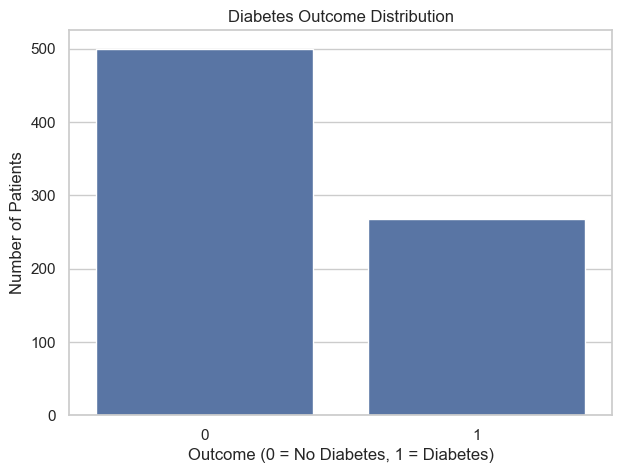

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=diabetes_clean,
    x='Outcome'
)

plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Number of Patients')

plt.show()

### Interpretation

The dataset contains 768 patients. Among them, 500 patients (65.1%) had Outcome 0, while 268 patients (34.9%) had Outcome 1.

This shows that the two outcome groups are not evenly distributed. There are substantially more patients without a diabetes outcome than patients with one.

Therefore, when comparing the groups, it is important to consider the difference in group sizes rather than relying only on raw counts.

In [30]:
outcome_percentages = (
    diabetes_clean['Outcome']
    .value_counts(normalize=True)
    .mul(100)
)

print(outcome_percentages)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


## Is Glucose Associated With Diabetes Outcome?

Glucose is an important variable to investigate because differences in glucose levels may help distinguish patients with different diabetes outcomes.

I will compare the average glucose level between the two outcome groups and then use a boxplot to examine the distribution and spread of glucose values.

In [31]:
diabetes_clean.groupby('Outcome')['Glucose'].mean()

Outcome
0    110.682000
1    142.130597
Name: Glucose, dtype: float64

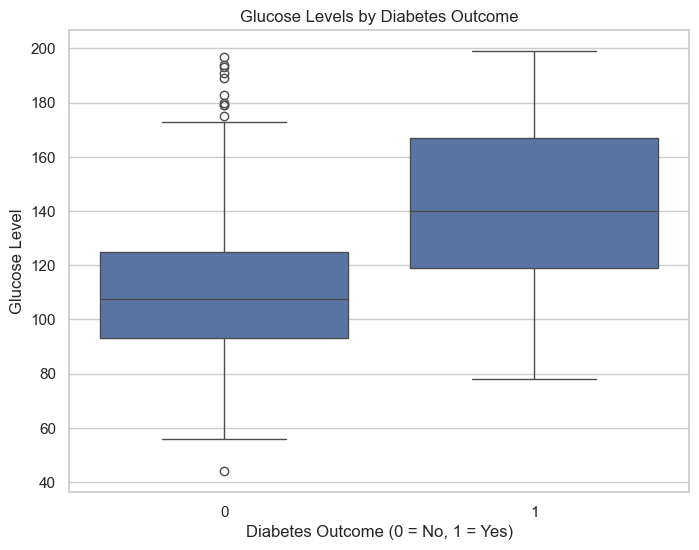

In [32]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=diabetes_clean,
    x='Outcome',
    y='Glucose'
)

plt.title('Glucose Levels by Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No, 1 = Yes)')
plt.ylabel('Glucose Level')

plt.show()

### Interpretation

The average glucose level was approximately 110.7 for patients with Outcome 0 and 142.1 for patients with Outcome 1.

This is a difference of approximately 31.4 units, with patients in the diabetes-outcome group having substantially higher glucose levels on average.

The boxplot also allows us to compare the spread and potential outliers in both groups. Overall, glucose appears to have a relatively strong association with the diabetes outcome in this dataset.

However, this analysis does not establish that glucose alone causes the outcome. Other patient characteristics may also contribute.

## Is BMI Associated With Diabetes Outcome?

BMI may provide information about differences between patients with and without a diabetes outcome. I will compare BMI across the two outcome groups and examine the distributions using a boxplot.

In [33]:
diabetes_clean.groupby('Outcome')['BMI'].mean()

Outcome
0    30.885600
1    35.383582
Name: BMI, dtype: float64

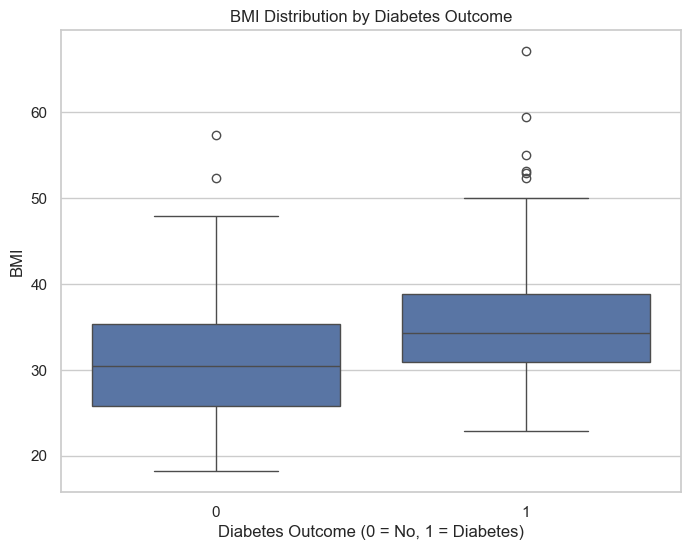

In [34]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=diabetes_clean,
    x='Outcome',
    y='BMI'
)

plt.title('BMI Distribution by Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No, 1 = Diabetes)')
plt.ylabel('BMI')

plt.show()

### Interpretation

The average BMI was approximately 30.9 among patients with Outcome 0 and 35.4 among patients with Outcome 1.

This indicates that patients with Outcome 1 had a higher average BMI in this dataset. The boxplot also allows us to examine the spread of BMI values and identify potential outliers.

The difference suggests that BMI is associated with diabetes outcome in this dataset, although the relationship is weaker than the relationship observed for glucose.

This should be interpreted as an association rather than evidence that BMI alone causes diabetes.

## Does Blood Pressure Differ Between Diabetes Outcome Groups?

I will compare the average blood pressure between patients with Outcome 0 and Outcome 1 and use a boxplot to examine whether the distributions differ.

In [35]:
diabetes_clean.groupby('Outcome')['BloodPressure'].mean()

Outcome
0    70.920000
1    75.123134
Name: BloodPressure, dtype: float64

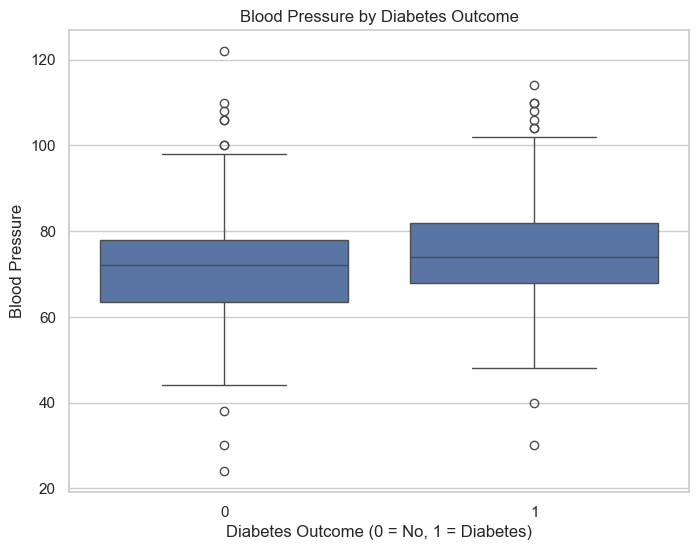

In [36]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=diabetes_clean,
    x='Outcome',
    y='BloodPressure'
)

plt.title('Blood Pressure by Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No, 1 = Diabetes)')
plt.ylabel('Blood Pressure')

plt.show()

### Interpretation

The average blood pressure was approximately 70.9 for patients with Outcome 0 and 75.1 for patients with Outcome 1.

Although the diabetes-outcome group had a higher average blood pressure, the difference is relatively small compared with the differences observed for glucose and BMI.

This suggests that blood pressure has a weaker association with the outcome in this dataset. The boxplot also helps determine whether the distributions overlap substantially between the two groups.

## Is Pregnancy History Associated With Diabetes Outcome?

Pregnancy history may differ between patients with different diabetes outcomes. I will compare the average number of pregnancies across the two outcome groups and examine their distributions using a boxplot.

In [37]:
diabetes_clean.groupby('Outcome')['Pregnancies'].mean()

Outcome
0    3.298000
1    4.865672
Name: Pregnancies, dtype: float64

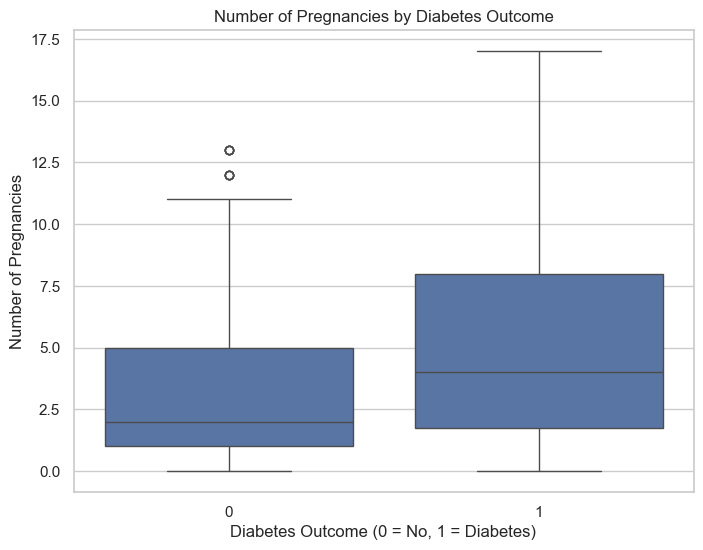

In [38]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=diabetes_clean,
    x='Outcome',
    y='Pregnancies'
)

plt.title('Number of Pregnancies by Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No, 1 = Diabetes)')
plt.ylabel('Number of Pregnancies')

plt.show()

### Interpretation

Patients with Outcome 1 had an average of approximately 4.9 pregnancies compared with 3.3 pregnancies among patients with Outcome 0.

This suggests an association between pregnancy history and diabetes outcome in this dataset. However, the correlation is relatively weak compared with glucose and BMI.

The result should therefore be interpreted as one possible relationship among several patient characteristics rather than as evidence that pregnancy history alone determines diabetes outcome.

## How Do Age and Glucose Relate to Diabetes Outcome Together?

The previous analyses examined variables individually. I now want to investigate whether age and glucose show a pattern when considered together.

A scatterplot allows me to examine the relationship between Age and Glucose while using Outcome to distinguish the two groups.

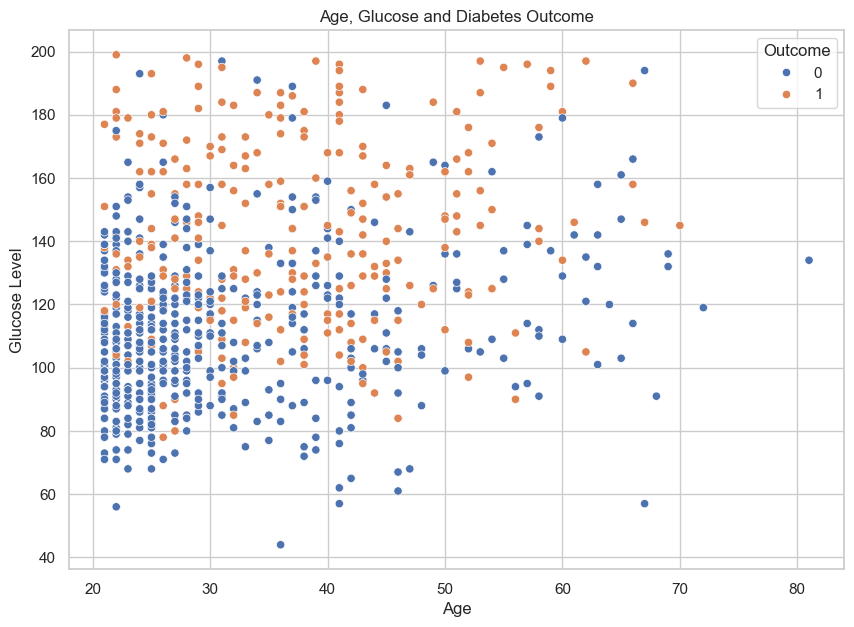

In [39]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=diabetes_clean,
    x='Age',
    y='Glucose',
    hue='Outcome'
)

plt.title('Age, Glucose and Diabetes Outcome')
plt.xlabel('Age')
plt.ylabel('Glucose Level')

plt.show()

### Interpretation

The scatterplot shows that patients with Outcome 1 tend to appear more frequently at higher glucose levels, while Outcome 0 is more common at lower glucose levels.

Age also varies across the dataset, but the separation between the outcome groups appears more noticeable along the glucose dimension than along age alone.

This suggests that glucose may provide stronger information about the diabetes outcome than age in this dataset. However, the scatterplot shows patterns and associations rather than proving causation.

## Which Variables Have the Strongest Association With Diabetes Outcome?

To compare the relationships between the numerical variables and the diabetes outcome, I calculated the Pearson correlation between each variable and Outcome.

Correlation values closer to +1 indicate a stronger positive linear relationship, while values closer to 0 indicate a weaker linear relationship.

Correlation does not imply causation, so these values will be used to identify patterns rather than to claim that one variable causes another.

In [40]:
correlation = diabetes_clean.corr(numeric_only=True)

print(
    correlation['Outcome']
    .sort_values(ascending=False)
)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


### Interpretation

Glucose has the strongest positive correlation with Outcome at approximately 0.49, followed by BMI at approximately 0.31.

Age and Pregnancies have weaker positive correlations of approximately 0.24 and 0.22 respectively. DiabetesPedigreeFunction and BloodPressure have weaker positive relationships.

Overall, glucose appears to be the variable most strongly associated with the diabetes outcome among the variables included in this cleaned dataset.

However, correlation measures linear association and does not prove causation. A stronger relationship with Outcome does not necessarily mean that the variable independently determines whether a patient has diabetes.

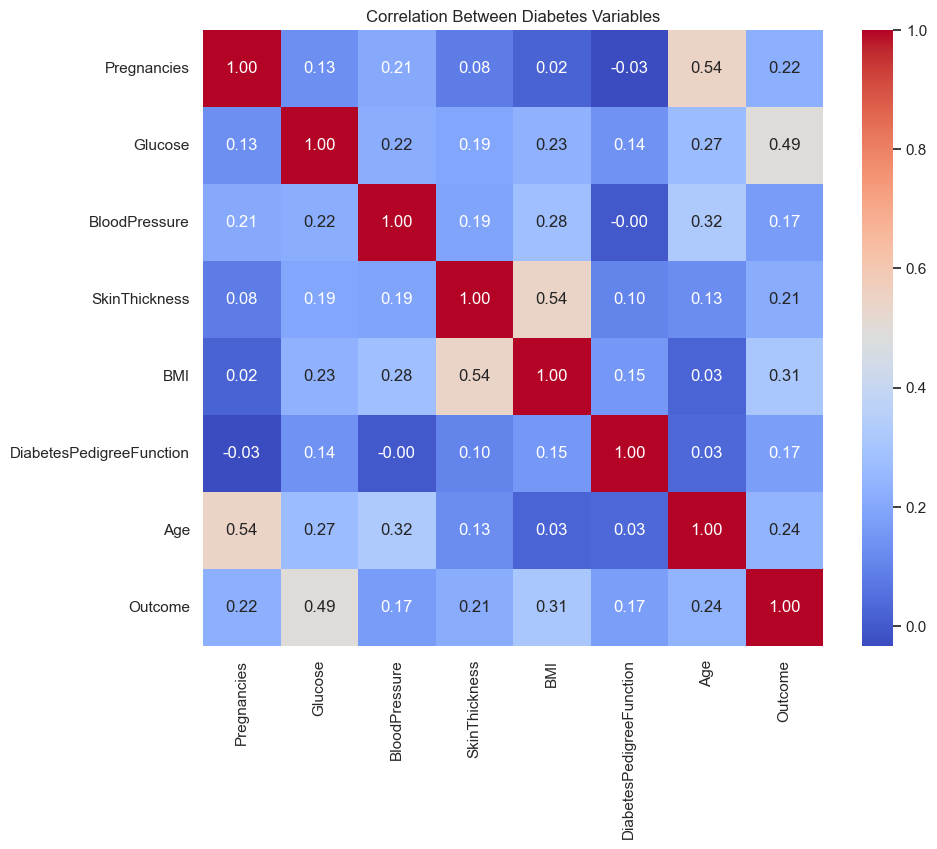

In [41]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Diabetes Variables')

plt.show()

### Interpretation

The correlation heatmap provides an overview of the relationships between the numerical variables.

The strongest visible relationship with Outcome is between Glucose and Outcome, followed by BMI and Outcome. This supports the earlier group comparisons, where patients with Outcome 1 had higher average glucose and BMI values.

The heatmap also helps identify relationships between the predictor variables themselves, which is useful because some variables may contain related information.

However, correlation only measures linear relationships and should not be interpreted as proof of causation.

## Comparing Patient Characteristics Across Outcomes

After examining individual variables separately, I will compare the average values of the main health indicators across the two outcome groups.

This allows the analysis to move beyond individual observations and identify which characteristics show the largest differences between patients with and without a diabetes outcome.

In [42]:
comparison = diabetes_clean.groupby('Outcome')[
    ['Pregnancies', 'Glucose', 'BloodPressure',
     'SkinThickness', 'BMI',
     'DiabetesPedigreeFunction', 'Age']
].mean().round(2)

comparison

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,
0,3.30,110.68,70.92,27.73,30.89,0.43,31.19
1,4.87,142.13,75.12,31.69,35.38,0.55,37.07


### Interpretation

The comparison shows that several characteristics differ between the two outcome groups.

The largest difference is observed in glucose levels, followed by BMI, BloodPressure and age. SkinThickness history also shows a noticeable difference, while the difference in Pregnancy is smaller.

This suggests that glucose may be particularly important in distinguishing the two groups within this dataset. However, these comparisons are descriptive and should not be interpreted as evidence that any individual variable causes diabetes.

# Final Findings and Recommendations

## Key Findings

Based on the analysis:

1. Patients with a diabetes outcome were older on average than patients without a diabetes outcome.

2. Glucose levels showed one of the clearest differences between the two groups, with patients having a diabetes outcome showing substantially higher average glucose levels.

3. Patients with a diabetes outcome also had higher average BMI.

4. Average blood pressure was higher among patients with a diabetes outcome, although the difference was smaller than those observed for glucose, BMI and age.

5. Patients with a diabetes outcome had a higher average number of pregnancies, suggesting a possible association between pregnancy history and diabetes outcome.

6. The correlation analysis showed relationships among several of the health variables, but correlations should not be interpreted as evidence of causation.

## Overall Conclusion

The analysis suggests that diabetes outcome is associated with several patient characteristics, particularly glucose level, BMI and age.

Among the variables examined, glucose showed one of the clearest differences between the two outcome groups. However, diabetes is a complex condition and the results should not be interpreted as meaning that one variable independently determines the outcome.

Further analysis using statistical tests or predictive modelling would be required to determine the statistical significance of these relationships and to evaluate how multiple variables work together.

## Recommendations

Based on the findings, future analysis could:

- Perform statistical significance tests to determine whether the observed differences between outcome groups are statistically meaningful.
- Examine how multiple variables jointly predict diabetes outcome rather than examining each variable separately.
- Investigate potential interactions between age, BMI and glucose.
- Consider using logistic regression as a next step because the outcome variable is binary.
- Evaluate model performance using appropriate classification metrics if predictive modelling is undertaken.
- Investigate the impact of missing-value treatment on the results through sensitivity analysis.